# 14. 서비스 고도화: 모델 배포 최적화 · 파이프라인 고도화 · 산업 데이터 처리 개선

## 학습 목표
1. 배포 관점에서 **지연시간·처리량·메모리**를 측정하고 최적화한다.
2. 분석 단계를 **버전 관리형 파이프라인**으로 재구성한다.
3. 산업 데이터(영상·센서) 처리의 **품질 게이트·증분 처리·스키마 검증**을 개선한다.

---

## 고도화 맵

```text
[원천 데이터] → [품질 게이트] → [전처리 파이프라인 vN]
        → [배치/캐시 추론] → [Fusion/LLM] → [모니터링 메트릭]
```

선행: `11` 핵심모듈, `13` 시스템통합

In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass, asdict, field
from datetime import datetime
from typing import Callable, Any
import hashlib
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "service_advancement"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("OUT_DIR:", OUT_DIR)

DATA_ROOT exists: True
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\service_advancement


## 1) 산업 데이터 처리 파이프라인 개선

개선 포인트:
- **스키마 검증** (필수 컬럼/타입/범위)
- **품질 게이트** (결측률·이상치 비율 임계값)
- **증분 처리** (이미 처리한 stem 스킵)
- **스테이지 버전** (재현 가능한 파이프라인 ID)

In [2]:
SENSOR_SCHEMA = {
    "t": {"dtype": "numeric", "min": 0},
    "lux": {"dtype": "numeric", "min": 0, "max": 5000},
    "temp": {"dtype": "numeric", "min": -20, "max": 80},
    "vibration": {"dtype": "numeric", "min": 0, "max": 5},
}


def validate_sensor_schema(df: pd.DataFrame) -> list[str]:
    errors = []
    for col, rule in SENSOR_SCHEMA.items():
        if col not in df.columns:
            errors.append(f"missing_column:{col}")
            continue
        if rule["dtype"] == "numeric" and not pd.api.types.is_numeric_dtype(df[col]):
            errors.append(f"non_numeric:{col}")
            continue
        if "min" in rule and (df[col] < rule["min"]).any():
            errors.append(f"below_min:{col}")
        if "max" in rule and (df[col] > rule["max"]).any():
            errors.append(f"above_max:{col}")
    return errors


def quality_gate_sensor(df: pd.DataFrame, max_missing_rate=0.05, max_outlier_rate=0.15) -> dict:
    missing_rate = float(df.isna().mean().mean())
    outlier_flags = []
    for c in ["lux", "temp", "vibration"]:
        if c not in df.columns:
            continue
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr = q3 - q1 + 1e-9
        outlier_flags.append(((df[c] < q1 - 3 * iqr) | (df[c] > q3 + 3 * iqr)).mean())
    outlier_rate = float(np.mean(outlier_flags)) if outlier_flags else 0.0

    passed = (missing_rate <= max_missing_rate) and (outlier_rate <= max_outlier_rate)
    return {
        "passed": passed,
        "missing_rate": missing_rate,
        "outlier_rate": outlier_rate,
        "max_missing_rate": max_missing_rate,
        "max_outlier_rate": max_outlier_rate,
    }


@dataclass
class PipelineState:
    """증분 처리 상태 저장소."""
    processed_ids: set[str] = field(default_factory=set)
    path: Path = field(default_factory=lambda: OUT_DIR / "pipeline_state.json")

    def load(self):
        if self.path.exists():
            data = json.loads(self.path.read_text(encoding="utf-8"))
            self.processed_ids = set(data.get("processed_ids", []))
        return self

    def save(self):
        self.path.write_text(
            json.dumps({"processed_ids": sorted(self.processed_ids), "updated_at": datetime.now().isoformat()}, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )

    def should_process(self, item_id: str) -> bool:
        return item_id not in self.processed_ids

    def mark_done(self, item_id: str):
        self.processed_ids.add(item_id)


# 데모 센서 데이터
rng = np.random.default_rng(14)
n = 100
sensor_ok = pd.DataFrame({
    "t": np.arange(n),
    "lux": 900 + rng.normal(0, 20, n),
    "temp": 24 + rng.normal(0, 0.1, n),
    "vibration": 0.05 + np.abs(rng.normal(0, 0.01, n)),
})
sensor_bad = sensor_ok.copy()
sensor_bad.loc[0:20, "lux"] = np.nan
sensor_bad["vibration"] = 10.0  # schema max 초과

print("OK schema errors:", validate_sensor_schema(sensor_ok))
print("BAD schema errors:", validate_sensor_schema(sensor_bad))
print("OK quality gate:", quality_gate_sensor(sensor_ok))
print("BAD quality gate:", quality_gate_sensor(sensor_bad))

OK schema errors: []
BAD schema errors: ['above_max:vibration']
OK quality gate: {'passed': True, 'missing_rate': 0.0, 'outlier_rate': 0.0, 'max_missing_rate': 0.05, 'max_outlier_rate': 0.15}
BAD quality gate: {'passed': False, 'missing_rate': 0.0525, 'outlier_rate': 0.0, 'max_missing_rate': 0.05, 'max_outlier_rate': 0.15}


## 2) 버전 관리형 처리 파이프라인 (DAG 스타일)

각 스테이지를 함수로 등록하고, 파이프라인 버전 해시로 재현성을 보장합니다.

In [3]:
@dataclass
class StageResult:
    name: str
    ok: bool
    data: Any
    metrics: dict
    elapsed_ms: float


class IndustrialPipeline:
    """산업 데이터 처리 파이프라인 (버전드 스테이지)."""

    def __init__(self, version: str = "v1.0.0"):
        self.version = version
        self.stages: list[tuple[str, Callable]] = []

    def add(self, name: str, fn: Callable):
        self.stages.append((name, fn))
        return self

    def fingerprint(self) -> str:
        names = "|".join(n for n, _ in self.stages)
        raw = f"{self.version}:{names}"
        return hashlib.sha1(raw.encode()).hexdigest()[:12]

    def run(self, payload: dict) -> dict:
        ctx = dict(payload)
        history = []
        t_all = time.perf_counter()

        for name, fn in self.stages:
            t0 = time.perf_counter()
            try:
                out = fn(ctx)
                ok = bool(out.get("ok", True))
                ctx.update(out.get("updates", {}))
                metrics = out.get("metrics", {})
            except Exception as e:
                ok = False
                metrics = {"error": str(e)}
            elapsed = (time.perf_counter() - t0) * 1000
            history.append(StageResult(name, ok, None, metrics, elapsed))
            if not ok:
                break

        return {
            "pipeline_version": self.version,
            "fingerprint": self.fingerprint(),
            "success": all(h.ok for h in history) and len(history) == len(self.stages),
            "total_ms": (time.perf_counter() - t_all) * 1000,
            "stages": [asdict(h) for h in history],
            "context": {k: v for k, v in ctx.items() if k not in {"gray", "sensor_df"}},
        }


def stage_schema(ctx: dict) -> dict:
    errs = validate_sensor_schema(ctx["sensor_df"])
    return {"ok": len(errs) == 0, "metrics": {"schema_errors": errs}}


def stage_quality(ctx: dict) -> dict:
    q = quality_gate_sensor(ctx["sensor_df"])
    return {"ok": q["passed"], "metrics": q}


def stage_clean(ctx: dict) -> dict:
    df = ctx["sensor_df"].copy()
    for c in ["lux", "temp", "vibration"]:
        df[c] = df[c].interpolate().bfill().ffill()
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr = q3 - q1
        df[c] = df[c].clip(q1 - 3 * iqr, q3 + 3 * iqr)
    return {"ok": True, "updates": {"sensor_clean": df}, "metrics": {"rows": len(df)}}


def stage_vision_features(ctx: dict) -> dict:
    g = ctx["gray"]
    mean, std = float(g.mean()), float(g.std())
    gx, gy = np.diff(g, axis=1), np.diff(g, axis=0)
    grad = float((gx**2).mean() + (gy**2).mean())
    edge = float((np.abs(gx) > 0.08).mean())
    feats = {"img_mean": mean, "img_std": std, "grad_energy": grad, "edge_ratio": edge}
    risk = float(np.clip(0.25 * min(1, grad / 0.03) + 0.35 * min(1, edge / 0.25) + 0.4 * min(1, abs(mean - 0.5) / 0.35), 0, 1))
    return {"ok": True, "updates": {"vision_feats": feats, "vision_risk": risk}, "metrics": {"vision_risk": risk}}


def stage_sensor_features(ctx: dict) -> dict:
    df = ctx.get("sensor_clean", ctx["sensor_df"])
    recent = df.tail(30)
    for c in ["lux", "temp", "vibration"]:
        df[f"{c}_z"] = (df[c] - df[c].mean()) / (df[c].std() + 1e-9)
    recent = df.tail(30)
    vib_z = float(recent["vibration_z"].abs().max())
    lux_z = float(recent["lux_z"].abs().max())
    temp_z = float(recent["temp_z"].abs().max())
    risk = float(np.clip(0.45 * min(1, vib_z / 3) + 0.3 * min(1, lux_z / 3) + 0.25 * min(1, temp_z / 3), 0, 1))
    return {"ok": True, "updates": {"sensor_risk": risk}, "metrics": {"sensor_risk": risk}}


def stage_fuse(ctx: dict) -> dict:
    w_v, w_s = 0.6, 0.4
    fused = w_v * ctx["vision_risk"] + w_s * ctx["sensor_risk"]
    level = "HIGH" if fused >= 0.75 else ("MEDIUM" if fused >= 0.45 else "LOW")
    return {"ok": True, "updates": {"fused_risk": fused, "risk_level": level}, "metrics": {"fused_risk": fused, "risk_level": level}}


pipe = (
    IndustrialPipeline(version="v2.1.0")
    .add("schema_validate", stage_schema)
    .add("quality_gate", stage_quality)
    .add("sensor_clean", stage_clean)
    .add("vision_features", stage_vision_features)
    .add("sensor_features", stage_sensor_features)
    .add("fuse", stage_fuse)
)

print("pipeline fingerprint:", pipe.fingerprint())
print("stages:", [n for n, _ in pipe.stages])

pipeline fingerprint: 9172c7056ad5
stages: ['schema_validate', 'quality_gate', 'sensor_clean', 'vision_features', 'sensor_features', 'fuse']


In [4]:
# 실제 이미지 + 센서로 파이프라인 실행
img_paths = sorted((DATA_ROOT / "test" / "images").glob("*.jpg"))
gray = np.array(Image.open(img_paths[0]).convert("L"), dtype=np.float32) / 255.0

# 정상 케이스
run_ok = pipe.run({"gray": gray, "sensor_df": sensor_ok, "lot_id": "LOT-PIPE-OK"})
# 품질 게이트 실패 케이스
run_ng = pipe.run({"gray": gray, "sensor_df": sensor_bad, "lot_id": "LOT-PIPE-NG"})

print("=== OK ===")
print(json.dumps({k: run_ok[k] for k in ["success", "fingerprint", "total_ms", "stages"]}, indent=2, ensure_ascii=False, default=str))
print("context:", {k: run_ok["context"].get(k) for k in ["vision_risk", "sensor_risk", "fused_risk", "risk_level"]})

print("\n=== NG (품질게이트 차단 기대) ===")
print("success:", run_ng["success"])
print("stopped_at:", run_ng["stages"][-1]["name"] if run_ng["stages"] else None)
print("metrics:", run_ng["stages"][-1]["metrics"] if run_ng["stages"] else None)

=== OK ===
{
  "success": true,
  "fingerprint": "9172c7056ad5",
  "total_ms": 12.820500007364899,
  "stages": [
    {
      "name": "schema_validate",
      "ok": true,
      "data": null,
      "metrics": {
        "schema_errors": []
      },
      "elapsed_ms": 0.43539999751374125
    },
    {
      "name": "quality_gate",
      "ok": true,
      "data": null,
      "metrics": {
        "passed": true,
        "missing_rate": 0.0,
        "outlier_rate": 0.0,
        "max_missing_rate": 0.05,
        "max_outlier_rate": 0.15
      },
      "elapsed_ms": 2.0800000056624413
    },
    {
      "name": "sensor_clean",
      "ok": true,
      "data": null,
      "metrics": {
        "rows": 100
      },
      "elapsed_ms": 4.321599961258471
    },
    {
      "name": "vision_features",
      "ok": true,
      "data": null,
      "metrics": {
        "vision_risk": 0.2837394305190263
      },
      "elapsed_ms": 4.233499988913536
    },
    {
      "name": "sensor_features",
      "ok": 

## 3) 모델 배포 최적화

실무에서 자주 쓰는 최적화:
1. **배치 추론** — 단건 대비 처리량 향상
2. **결과 캐시** — 동일 입력 재계산 방지
3. **경량 표현(양자화 시뮬레이션)** — float32 → float16 메모리 절감
4. **지연시간 프로파일** — p50/p95 측정

In [5]:
class InferenceCache:
    def __init__(self):
        self.store: dict[str, dict] = {}
        self.hits = 0
        self.misses = 0

    def key(self, arr: np.ndarray) -> str:
        # 이미지 해시 (배포 캐시 키 예시)
        return hashlib.md5(arr.tobytes()).hexdigest()

    def get(self, k: str):
        if k in self.store:
            self.hits += 1
            return self.store[k]
        self.misses += 1
        return None

    def put(self, k: str, v: dict):
        self.store[k] = v


def extract_vision_fp32(gray: np.ndarray) -> dict:
    mean, std = float(gray.mean()), float(gray.std())
    gx, gy = np.diff(gray, axis=1), np.diff(gray, axis=0)
    grad = float((gx**2).mean() + (gy**2).mean())
    edge = float((np.abs(gx) > 0.08).mean())
    return {"img_mean": mean, "img_std": std, "grad_energy": grad, "edge_ratio": edge}


def extract_vision_fp16(gray: np.ndarray) -> dict:
    g = gray.astype(np.float16).astype(np.float32)  # 양자화 시뮬레이션
    return extract_vision_fp32(g)


def bench_single(images: list[np.ndarray], fn: Callable, use_cache=False, cache=None) -> dict:
    lat = []
    for im in images:
        t0 = time.perf_counter()
        if use_cache and cache is not None:
            k = cache.key(im)
            hit = cache.get(k)
            if hit is None:
                out = fn(im)
                cache.put(k, out)
            else:
                out = hit
        else:
            out = fn(im)
        lat.append((time.perf_counter() - t0) * 1000)
    arr = np.array(lat)
    return {
        "n": len(images),
        "p50_ms": float(np.percentile(arr, 50)),
        "p95_ms": float(np.percentile(arr, 95)),
        "mean_ms": float(arr.mean()),
        "throughput_img_s": float(1000.0 / (arr.mean() + 1e-9)),
    }


def bench_batch(images: list[np.ndarray], batch_size=8) -> dict:
    """배치 단위로 묶어 처리 (루프 오버헤드 감소 시뮬레이션)."""
    lat = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        t0 = time.perf_counter()
        # 배치 스택 후 일괄 통계 (단순 예시)
        stack = np.stack(batch, axis=0)
        _ = stack.mean(axis=(1, 2))
        _ = stack.std(axis=(1, 2))
        lat.append((time.perf_counter() - t0) * 1000)
    per_img = np.array(lat) / batch_size
    # 마지막 배치 크기 보정은 생략(벤치 근사)
    return {
        "batch_size": batch_size,
        "mean_ms_per_img": float(per_img.mean()),
        "throughput_img_s": float(1000.0 / (per_img.mean() + 1e-9)),
    }


# 벤치 이미지 준비
bench_imgs = []
for p in img_paths[:40]:
    bench_imgs.append(np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0)

cache = InferenceCache()
# 워밍업 + 동일 이미지 재요청으로 캐시 효과 측정
warmup = bench_imgs[:10]
dup = warmup + warmup  # 2회 반복 → 캐시 hit 유도

m_fp32 = bench_single(bench_imgs, extract_vision_fp32, use_cache=False)
m_fp16 = bench_single(bench_imgs, extract_vision_fp16, use_cache=False)
m_cache = bench_single(dup, extract_vision_fp32, use_cache=True, cache=cache)
m_batch4 = bench_batch(bench_imgs, batch_size=4)
m_batch8 = bench_batch(bench_imgs, batch_size=8)

bench_df = pd.DataFrame([
    {"mode": "single_fp32", **{k: m_fp32[k] for k in ["mean_ms", "p50_ms", "p95_ms", "throughput_img_s"]}},
    {"mode": "single_fp16", **{k: m_fp16[k] for k in ["mean_ms", "p50_ms", "p95_ms", "throughput_img_s"]}},
    {"mode": "cached_fp32", "mean_ms": m_cache["mean_ms"], "p50_ms": m_cache["p50_ms"], "p95_ms": m_cache["p95_ms"], "throughput_img_s": m_cache["throughput_img_s"]},
    {"mode": "batch4", "mean_ms": m_batch4["mean_ms_per_img"], "p50_ms": np.nan, "p95_ms": np.nan, "throughput_img_s": m_batch4["throughput_img_s"]},
    {"mode": "batch8", "mean_ms": m_batch8["mean_ms_per_img"], "p50_ms": np.nan, "p95_ms": np.nan, "throughput_img_s": m_batch8["throughput_img_s"]},
])

print(f"cache hits={cache.hits}, misses={cache.misses}, hit_rate={cache.hits/(cache.hits+cache.misses+1e-9):.1%}")
display(bench_df)

cache hits=10, misses=10, hit_rate=50.0%


,mode,mean_ms,p50_ms,p95_ms,throughput_img_s
0,single_fp32,3.318170,3.2090,4.137865,301.370936
1,single_fp16,4.598595,4.3114,6.244330,217.457723
2,cached_fp32,3.928770,3.6452,5.995955,254.532589
3,batch4,1.205008,NaN,NaN,829.870352
4,batch8,1.508765,NaN,NaN,662.793742


## 4) 증분 처리 + 배치 파이프라인 고도화

이미 처리한 Lot/이미지를 건너뛰어 재처리 비용을 줄입니다.

In [6]:
state = PipelineState().load()

def make_sensor_for_lot(seed: int, anomaly=False) -> pd.DataFrame:
    r = np.random.default_rng(seed)
    t = np.arange(80)
    df = pd.DataFrame({
        "t": t,
        "lux": 920 + r.normal(0, 15, 80),
        "temp": 24 + r.normal(0, 0.08, 80),
        "vibration": 0.05 + np.abs(r.normal(0, 0.008, 80)),
    })
    if anomaly:
        df.loc[55:, "vibration"] += 0.05
        df.loc[55:, "lux"] -= 120
    return df


batch_lots = [
    {"lot_id": f"LOT-ADV-{i:03d}", "img_idx": i % min(20, len(img_paths)), "anomaly": i % 4 == 0}
    for i in range(12)
]

# 1차 실행
results_1 = []
for lot in batch_lots:
    if not state.should_process(lot["lot_id"]):
        results_1.append({"lot_id": lot["lot_id"], "status": "skipped"})
        continue
    g = np.array(Image.open(img_paths[lot["img_idx"]]).convert("L"), dtype=np.float32) / 255.0
    sdf = make_sensor_for_lot(seed=100 + lot["img_idx"], anomaly=lot["anomaly"])
    out = pipe.run({"gray": g, "sensor_df": sdf, "lot_id": lot["lot_id"]})
    if out["success"]:
        state.mark_done(lot["lot_id"])
    results_1.append({
        "lot_id": lot["lot_id"],
        "status": "processed" if out["success"] else "failed",
        "fused_risk": out["context"].get("fused_risk"),
        "risk_level": out["context"].get("risk_level"),
        "total_ms": round(out["total_ms"], 2),
    })
state.save()

# 2차 실행 (대부분 skip 기대)
results_2 = []
for lot in batch_lots:
    if not state.should_process(lot["lot_id"]):
        results_2.append({"lot_id": lot["lot_id"], "status": "skipped"})
        continue
    results_2.append({"lot_id": lot["lot_id"], "status": "processed"})

df1 = pd.DataFrame(results_1)
df2 = pd.DataFrame(results_2)
print("1차 실행 상태 분포:")
display(df1["status"].value_counts())
print("2차 실행 상태 분포 (증분):")
display(df2["status"].value_counts())
display(df1.head())

1차 실행 상태 분포:


status
processed    12
Name: count, dtype: int64

2차 실행 상태 분포 (증분):


status
skipped    12
Name: count, dtype: int64

,lot_id,status,fused_risk,risk_level,total_ms
0,LOT-ADV-000,processed,0.452909,MEDIUM,14.08
1,LOT-ADV-001,processed,0.462570,MEDIUM,10.61
2,LOT-ADV-002,processed,0.425894,LOW,9.95
3,LOT-ADV-003,processed,0.512803,MEDIUM,11.48
4,LOT-ADV-004,processed,0.447006,LOW,10.19


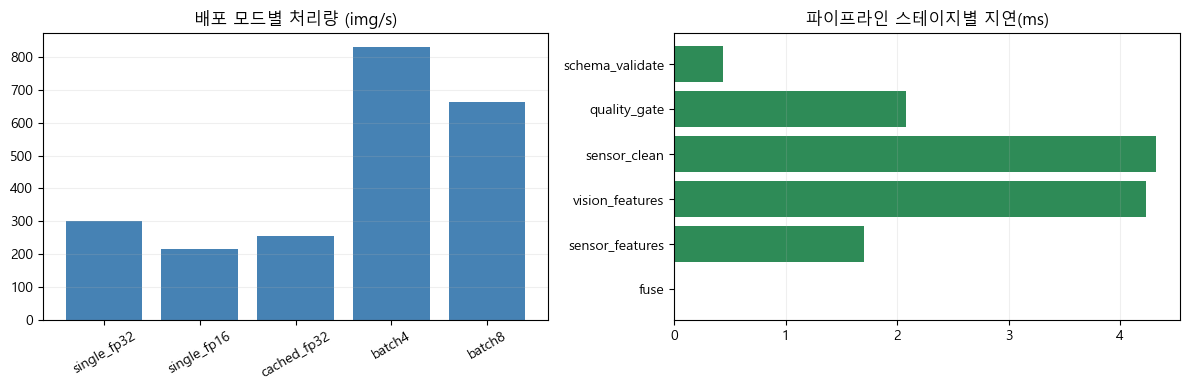

이미지 1장 메모리: fp32=1406.2KB, fp16=703.1KB, 절감=50%


In [7]:
# 시각화: 배포 최적화 효과 + 파이프라인 스테이지 지연
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(bench_df["mode"], bench_df["throughput_img_s"], color="steelblue")
axes[0].set_title("배포 모드별 처리량 (img/s)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.2)

stage_ms = pd.DataFrame(run_ok["stages"])
axes[1].barh(stage_ms["name"], stage_ms["elapsed_ms"], color="seagreen")
axes[1].set_title("파이프라인 스테이지별 지연(ms)")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# 메모리 footprint 비교 (대략)
bytes_fp32 = bench_imgs[0].nbytes
bytes_fp16 = bench_imgs[0].astype(np.float16).nbytes
print(f"이미지 1장 메모리: fp32={bytes_fp32/1024:.1f}KB, fp16={bytes_fp16/1024:.1f}KB, 절감={(1-bytes_fp16/bytes_fp32):.0%}")

## 5) 배포 체크리스트 & 운영 메트릭

| 항목 | 목표 예시 | 본 노트북 측정 |
|------|----------|----------------|
| p95 latency | < 100ms (feature 추출) | `bench_df.p95_ms` |
| throughput | 라인 속도 대응 | `throughput_img_s` |
| cache hit rate | > 30% (재검사 구간) | hits/(hits+misses) |
| 품질 게이트 차단율 | 불량 입력 사전 차단 | NG 파이프라인 실패 |
| 증분 skip율 | 재실행 시 높음 | 2차 skipped 비율 |

In [8]:
# 산출물 저장
bench_df.to_csv(OUT_DIR / "deploy_benchmark.csv", index=False, encoding="utf-8-sig")
df1.to_csv(OUT_DIR / "batch_pipeline_run1.csv", index=False, encoding="utf-8-sig")
df2.to_csv(OUT_DIR / "batch_pipeline_run2_incremental.csv", index=False, encoding="utf-8-sig")

adv_report = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "pipeline": {
        "version": pipe.version,
        "fingerprint": pipe.fingerprint(),
        "stages": [n for n, _ in pipe.stages],
        "ok_run_success": run_ok["success"],
        "ng_run_success": run_ng["success"],
        "ok_total_ms": run_ok["total_ms"],
    },
    "deployment": {
        "benchmark": bench_df.to_dict(orient="records"),
        "cache_hits": cache.hits,
        "cache_misses": cache.misses,
        "cache_hit_rate": cache.hits / (cache.hits + cache.misses + 1e-9),
        "fp16_memory_saving": 1 - bytes_fp16 / bytes_fp32,
    },
    "incremental": {
        "run1_processed": int((df1["status"] == "processed").sum()),
        "run2_skipped": int((df2["status"] == "skipped").sum()),
        "skip_rate_run2": float((df2["status"] == "skipped").mean()),
    },
    "recommendations": [
        "라인 피크 시간대는 batch_size=8 추론으로 처리량 확보",
        "재검사 Lot은 InferenceCache로 중복 계산 제거",
        "스키마/품질 게이트 실패는 추론 전에 차단해 GPU 낭비 방지",
        "파이프라인 fingerprint를 모델 카드/릴리즈 노트에 기록",
    ],
}

with open(OUT_DIR / "service_advancement_report.json", "w", encoding="utf-8") as f:
    json.dump(adv_report, f, ensure_ascii=False, indent=2)

# 배포용 설정 템플릿
deploy_cfg = {
    "model_serving": {
        "batch_size": 8,
        "enable_cache": True,
        "precision": "fp16",
        "max_latency_p95_ms": 100,
    },
    "data_pipeline": {
        "version": pipe.version,
        "quality_gate": {"max_missing_rate": 0.05, "max_outlier_rate": 0.15},
        "incremental": True,
    },
}
with open(OUT_DIR / "deploy_config_template.json", "w", encoding="utf-8") as f:
    json.dump(deploy_cfg, f, ensure_ascii=False, indent=2)

print("저장 완료:")
for fn in [
    "deploy_benchmark.csv",
    "batch_pipeline_run1.csv",
    "batch_pipeline_run2_incremental.csv",
    "service_advancement_report.json",
    "deploy_config_template.json",
    "pipeline_state.json",
]:
    print("-", OUT_DIR / fn)

display(pd.DataFrame([
    {"metric": "cache_hit_rate", "value": adv_report["deployment"]["cache_hit_rate"]},
    {"metric": "fp16_memory_saving", "value": adv_report["deployment"]["fp16_memory_saving"]},
    {"metric": "incremental_skip_rate_run2", "value": adv_report["incremental"]["skip_rate_run2"]},
    {"metric": "pipeline_ok_ms", "value": run_ok["total_ms"]},
]))

저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\service_advancement\deploy_benchmark.csv
- C:\MyCursorLab\10_프로젝트\outputs\service_advancement\batch_pipeline_run1.csv
- C:\MyCursorLab\10_프로젝트\outputs\service_advancement\batch_pipeline_run2_incremental.csv
- C:\MyCursorLab\10_프로젝트\outputs\service_advancement\service_advancement_report.json
- C:\MyCursorLab\10_프로젝트\outputs\service_advancement\deploy_config_template.json
- C:\MyCursorLab\10_프로젝트\outputs\service_advancement\pipeline_state.json


,metric,value
0,cache_hit_rate,0.5000
1,fp16_memory_saving,0.5000
2,incremental_skip_rate_run2,1.0000
3,pipeline_ok_ms,12.8205


## 실습 과제

1. `batch_size`를 2/4/8/16으로 바꿔 처리량 곡선을 그리세요.
2. 품질 게이트 임계값을 강화해 차단율을 측정하세요.
3. 파이프라인에 `stage_llm_summary`를 추가해 E2E 지연을 비교하세요.
4. `deploy_config_template.json`을 13번 웹 서비스 설정과 병합하세요.

---

### 한 줄 정리
서비스 고도화는 **더 복잡한 모델**보다, **검증된 파이프라인 + 배포 최적화 + 증분 처리**로 현장 처리량과 안정성을 올리는 일입니다.